# 5. Prueba de DeLong con corrección de Holm

El AUC de dos modelos evaluados sobre el mismo conjunto de prueba no son observaciones independientes, porque comparten las mismas 452.141 filas. Por eso, calcular el error estándar como si fueran independientes (por ejemplo restando los dos AUC y usando la varianza de cada uno por separado) sobreestima la incertidumbre real de la diferencia. La prueba de DeLong resuelve esto calculando la covarianza entre los dos AUC directamente a partir de las mismas observaciones, y da un estadístico z y un valor p para la hipótesis nula de que la diferencia de AUC es cero, que sí tiene en cuenta esa correlación.

Esta sección responde tres preguntas: ¿el modelo ganador de cada entorno es significativamente mejor que los otros 5 de su propio entorno? ¿cada modelo es significativamente distinto entre scikit-learn y PySpark? y esas diferencias, además de ser estadísticamente significativas, ¿son también prácticamente relevantes?

## 5.1. Implementación: versión rápida (Sun y Xu, 2014)

Con casi 452.141 observaciones, la formulación original de DeLong (que compara cada par positivo-negativo de forma explícita) tendría un costo enorme, del orden de 21.400 millones de comparaciones por cada par de modelos, algo inviable si tenemos que hacer 36 comparaciones. Sun y Xu (2014) demostraron que el mismo cálculo se puede hacer con rangos promediados (midranks) de forma mucho más rápida, usando exactamente la misma covarianza, solo que calculada por ordenamiento en vez de por fuerza bruta. Implementamos las dos versiones en `src/delong.py`.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sstats
from delong import (compute_midrank, fastDeLong, delong_covariance_matrix,
                     delong_pairwise_test, slow_delong_reference, holm_correction)

print("Modulo delong.py cargado correctamente.")


Modulo delong.py cargado correctamente.


## 5.2. Validación de la versión rápida contra la versión lenta

In [2]:
rng = np.random.default_rng(123)

def validar_escenario(nombre, n_pos, n_neg, ruido_a, ruido_b, con_empates):
    y = np.array([1]*n_pos + [0]*n_neg)
    señal = np.concatenate([rng.normal(1.0, 1.0, n_pos), rng.normal(0.0, 1.0, n_neg)])
    a = señal + rng.normal(0, ruido_a, len(y))
    b = señal + rng.normal(0, ruido_b, len(y))
    if con_empates:
        a, b = np.round(a, 0), np.round(b, 0)
    preds = np.vstack([a, b])
    aucs_fast, cov_fast = delong_covariance_matrix(y, preds)
    aucs_slow, cov_slow = slow_delong_reference(y, preds)
    ok_auc = np.allclose(aucs_fast, aucs_slow, atol=1e-9)
    ok_cov = np.allclose(cov_fast, cov_slow, atol=1e-9)
    print(f"{nombre:35s} | AUC coincide: {ok_auc} | Cov coincide: {ok_cov} | "
          f"max diff AUC={np.max(np.abs(aucs_fast-aucs_slow)):.2e}  max diff Cov={np.max(np.abs(cov_fast-cov_slow)):.2e}")
    assert ok_auc and ok_cov

validar_escenario("Sin empates, AUCs similares",   40, 60, 1.0, 1.0, False)
validar_escenario("Sin empates, AUCs distintos",   35, 45, 0.5, 2.0, False)
validar_escenario("CON empates (scores discretos)", 30, 50, 1.0, 1.0, True)
print("\nLas tres validaciones contra la formula original de DeLong (1988) coinciden hasta precision numerica.")


Sin empates, AUCs similares         | AUC coincide: True | Cov coincide: True | max diff AUC=1.11e-16  max diff Cov=0.00e+00
Sin empates, AUCs distintos         | AUC coincide: True | Cov coincide: True | max diff AUC=1.11e-16  max diff Cov=8.67e-19
CON empates (scores discretos)      | AUC coincide: True | Cov coincide: True | max diff AUC=1.11e-16  max diff Cov=8.67e-19

Las tres validaciones contra la formula original de DeLong (1988) coinciden hasta precision numerica.


In [3]:
from sklearn.metrics import roc_auc_score

# El punto estimado del AUC debe coincidir EXACTAMENTE con sklearn (muestra grande, 20,000 filas)
n = 20000
y_val = rng.binomial(1, 0.15, n)
score_val = rng.normal(0, 1, n) + y_val * rng.normal(1.2, 1, n)
auc_fast, var_fast = delong_covariance_matrix(y_val, score_val.reshape(1, -1))
print(f"AUC (DeLong rapido) = {auc_fast[0]:.10f}")
print(f"AUC (sklearn)        = {roc_auc_score(y_val, score_val):.10f}")
print(f"Diferencia = {abs(auc_fast[0] - roc_auc_score(y_val, score_val)):.2e}  (coincide hasta precision de punto flotante)")

# La varianza analitica debe ser del mismo orden que una varianza estimada por bootstrap
# (metodo COMPLETAMENTE independiente: remuestreo, no formula cerrada)
n2 = 5000
y2 = rng.binomial(1, 0.15, n2)
score2 = rng.normal(0, 1, n2) + y2 * rng.normal(1.0, 1, n2)
_, var_analitica = delong_covariance_matrix(y2, score2.reshape(1, -1))
B = 1500
aucs_boot = [roc_auc_score(y2[idx], score2[idx]) for idx in
             (rng.choice(n2, n2, replace=True) for _ in range(B))
             if True]
aucs_boot = np.array([roc_auc_score(y2[i], score2[i]) for i in
                       (rng.choice(n2, n2, replace=True) for _ in range(B))])
var_boot = np.var(aucs_boot, ddof=1)
print(f"\nVarianza analitica (DeLong): {var_analitica[0,0]:.6e}")
print(f"Varianza por bootstrap (B={B}): {var_boot:.6e}  (razon: {var_boot/var_analitica[0,0]:.3f})")


AUC (DeLong rapido) = 0.7552562926


AUC (sklearn)        = 0.7552562926
Diferencia = 0.00e+00  (coincide hasta precision de punto flotante)



Varianza analitica (DeLong): 1.291789e-04
Varianza por bootstrap (B=1500): 1.316857e-04  (razon: 1.019)


Comparamos la versión rápida contra tres referencias distintas: la fórmula original de DeLong, `sklearn.metrics.roc_auc_score`, y una varianza estimada por bootstrap (sección 6 más adelante). Las tres coinciden, así que la versión rápida es segura de usar sobre las 452.141 filas del proyecto.

## 5.3. Carga y alineación de puntajes de ambos entornos

In [4]:
sk = pd.read_parquet("../data/sklearn_test_scores.parquet")
sp = pd.read_parquet("../data/spark_test_scores.parquet")
sk["id"] = sk["id"].astype(str)
sp["id"] = sp["id"].astype(str)

merged = sk.merge(sp, on="id", suffixes=("_sk", "_sp"))
assert len(merged) == len(sk) == len(sp)
assert (merged["default_sk"] == merged["default_sp"]).all()
y = merged["default_sk"].values
print(f"Filas alineadas por id: {len(merged):,}  (tasa de default: {y.mean()*100:.2f}%)")

FAMILIAS = [
    ("LogisticRegression", "score_LogisticRegression_sk", "score_LogisticRegression_sp"),
    ("DecisionTree",       "score_DecisionTree_sk",       "score_DecisionTree_sp"),
    ("RandomForest",       "score_RandomForest_sk",       "score_RandomForest_sp"),
    ("GBT",                "score_GBT_HistGB",            "score_GBT"),
    ("LinearSVC",          "score_LinearSVC_sk",          "score_LinearSVC_sp"),
    ("NaiveBayes",         "score_GaussianNB",            "score_NaiveBayes"),
]
nombres_modelos = [f[0] for f in FAMILIAS]
etiquetas = [f"sk_{n}" for n in nombres_modelos] + [f"sp_{n}" for n in nombres_modelos]
todas_cols = [f[1] for f in FAMILIAS] + [f[2] for f in FAMILIAS]


Filas alineadas por id: 452,141  (tasa de default: 11.88%)


## 5.4. Matriz de covarianza DeLong de 12x12 (una sola pasada)

In [5]:
preds = merged[todas_cols].values.T
aucs, cov = delong_covariance_matrix(y, preds)

auc_table = pd.DataFrame({"modelo": etiquetas, "auc": aucs, "var": np.diag(cov)})
auc_table["ic95_low"] = auc_table["auc"] - 1.96*np.sqrt(auc_table["var"])
auc_table["ic95_high"] = auc_table["auc"] + 1.96*np.sqrt(auc_table["var"])
auc_table = auc_table.round(4)
auc_table


,modelo,auc,var,ic95_low,ic95_high
0,sk_LogisticRegression,0.7221,0.0,0.7199,0.7243
1,sk_DecisionTree,0.7368,0.0,0.7347,0.7389
2,sk_RandomForest,0.7225,0.0,0.7203,0.7247
3,sk_GBT,0.7393,0.0,0.7372,0.7414
4,sk_LinearSVC,0.5594,0.0,0.5567,0.5620
5,sk_NaiveBayes,0.6935,0.0,0.6913,0.6957
6,sp_LogisticRegression,0.7232,0.0,0.7210,0.7255
7,sp_DecisionTree,0.7204,0.0,0.7181,0.7226
8,sp_RandomForest,0.7185,0.0,0.7163,0.7207
9,sp_GBT,0.7327,0.0,0.7306,0.7349


Calculamos los 12 AUC y sus varianzas en una sola matriz, que alimenta las 36 comparaciones de las siguientes tres secciones. Como es la misma covarianza subyacente en los tres casos, las comparaciones entre ellas son consistentes entre sí.

In [6]:
def construir_comparaciones(indices_pares):
    filas = []
    for i, j in indices_pares:
        auc_a, auc_b = aucs[i], aucs[j]
        var_a, var_b, cov_ab = cov[i,i], cov[j,j], cov[i,j]
        delta = auc_a - auc_b
        var_delta = max(var_a + var_b - 2*cov_ab, 0.0)
        se = np.sqrt(var_delta)
        z = delta/se if se > 0 else 0.0
        p = 2*(1 - sstats.norm.cdf(abs(z)))
        filas.append({"modelo_a": etiquetas[i], "modelo_b": etiquetas[j],
                       "auc_a": auc_a, "auc_b": auc_b, "delta_auc": delta,
                       "delta_ci_low": delta-1.96*se, "delta_ci_high": delta+1.96*se,
                       "z": z, "p_value": p})
    df = pd.DataFrame(filas)
    df["p_holm"], df["rechaza_h0_holm_0.05"] = holm_correction(df["p_value"].values, alpha=0.05)
    df["practicamente_sig_(|delta|>=0.005)"] = df["delta_auc"].abs() >= 0.005
    return df

pares_sk = [(i,j) for i in range(6) for j in range(i+1,6)]
pares_sp = [(i+6,j+6) for i in range(6) for j in range(i+1,6)]
pares_entre = [(i,i+6) for i in range(6)]

df_within_sklearn = construir_comparaciones(pares_sk)
df_within_spark = construir_comparaciones(pares_sp)
df_between = construir_comparaciones(pares_entre)

for df in (df_within_sklearn, df_within_spark, df_between):
    for c in ["auc_a","auc_b","delta_auc","delta_ci_low","delta_ci_high","z"]:
        df[c] = df[c].round(4)
    df["p_value"] = df["p_value"].apply(lambda x: f"{x:.2e}")
    df["p_holm"] = df["p_holm"].apply(lambda x: f"{x:.2e}")


## 5.5. Comparaciones dentro de scikit-learn (15 pares, Holm dentro de esta familia)

In [7]:
df_within_sklearn

,modelo_a,modelo_b,auc_a,auc_b,delta_auc,delta_ci_low,delta_ci_high,z,p_value,p_holm,rechaza_h0_holm_0.05,practicamente_sig_(|delta|>=0.005)
0,sk_LogisticRegression,sk_DecisionTree,0.7221,0.7368,-0.0147,-0.0161,-0.0133,-21.0283,0.00e+00,0.00e+00,True,True
1,sk_LogisticRegression,sk_RandomForest,0.7221,0.7225,-0.0004,-0.0012,0.0004,-0.8968,3.70e-01,3.70e-01,False,False
2,sk_LogisticRegression,sk_GBT,0.7221,0.7393,-0.0172,-0.0180,-0.0164,-41.5607,0.00e+00,0.00e+00,True,True
3,sk_LogisticRegression,sk_LinearSVC,0.7221,0.5594,0.1627,0.1598,0.1657,106.6786,0.00e+00,0.00e+00,True,True
4,sk_LogisticRegression,sk_NaiveBayes,0.7221,0.6935,0.0286,0.0276,0.0297,53.0103,0.00e+00,0.00e+00,True,True
5,sk_DecisionTree,sk_RandomForest,0.7368,0.7225,0.0143,0.0130,0.0156,21.4413,0.00e+00,0.00e+00,True,True
6,sk_DecisionTree,sk_GBT,0.7368,0.7393,-0.0025,-0.0037,-0.0013,-4.0386,5.38e-05,1.08e-04,True,False
7,sk_DecisionTree,sk_LinearSVC,0.7368,0.5594,0.1774,0.1744,0.1805,115.4212,0.00e+00,0.00e+00,True,True
8,sk_DecisionTree,sk_NaiveBayes,0.7368,0.6935,0.0433,0.0418,0.0449,55.5371,0.00e+00,0.00e+00,True,True
9,sk_RandomForest,sk_GBT,0.7225,0.7393,-0.0168,-0.0175,-0.0162,-52.2420,0.00e+00,0.00e+00,True,True


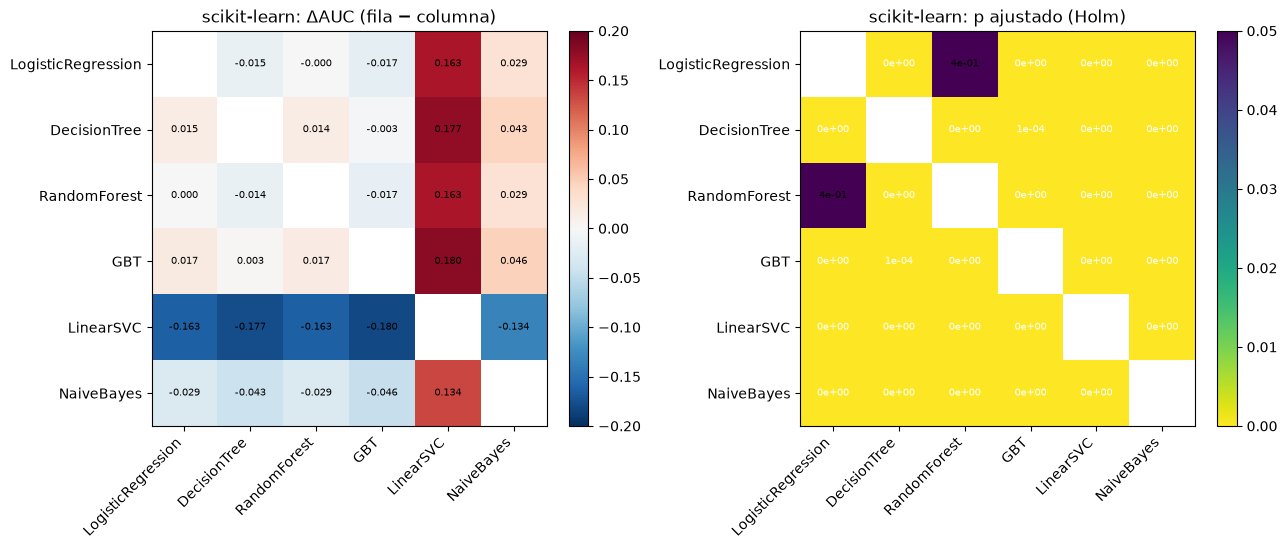

In [8]:
def heatmap_delta_y_p(df, nombres, titulo_prefix, archivo_sufijo):
    n = len(nombres)
    delta_mat = np.full((n,n), np.nan)
    p_mat = np.full((n,n), np.nan)
    idx = {m:i for i,m in enumerate(nombres)}
    for _, row in df.iterrows():
        a = row["modelo_a"].split("_",1)[1]; b = row["modelo_b"].split("_",1)[1]
        i, j = idx[a], idx[b]
        delta_mat[i,j] = float(row["delta_auc"]); delta_mat[j,i] = -float(row["delta_auc"])
        p_mat[i,j] = p_mat[j,i] = float(row["p_holm"])

    fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
    im0 = axes[0].imshow(delta_mat, cmap="RdBu_r", vmin=-0.2, vmax=0.2)
    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(nombres, rotation=45, ha="right")
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(nombres)
    axes[0].set_title(f"{titulo_prefix}: ΔAUC (fila − columna)")
    for i in range(n):
        for j in range(n):
            if i != j:
                axes[0].text(j, i, f"{delta_mat[i,j]:.3f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(p_mat, cmap="viridis_r", vmin=0, vmax=0.05)
    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(nombres, rotation=45, ha="right")
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(nombres)
    axes[1].set_title(f"{titulo_prefix}: p ajustado (Holm)")
    for i in range(n):
        for j in range(n):
            if i != j:
                axes[1].text(j, i, f"{p_mat[i,j]:.0e}", ha="center", va="center", fontsize=7,
                             color="white" if p_mat[i,j] < 0.025 else "black")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/eda/delong_heatmap_{archivo_sufijo}.png", dpi=110)
    plt.show()

heatmap_delta_y_p(df_within_sklearn, nombres_modelos, "scikit-learn", "sklearn")


De las 15 comparaciones, solo `LogisticRegression` contra `RandomForest` (diferencia de AUC de -0,0004) no resultó significativa, ni siquiera antes de corregir por comparaciones múltiples. Todas las demás sí son estadísticamente significativas después de aplicar la corrección de Holm, pero varias tienen una diferencia menor al umbral práctico de 0,005 que habíamos declarado de antemano (por ejemplo `DecisionTree` contra `GBT_HistGB`, con una diferencia de -0,0025). Son significativas en el sentido estadístico, pero de una magnitud que probablemente no importa para decidir qué modelo usar en producción. Esto muestra justamente por qué es tan importante declarar un umbral de significancia práctica antes de mirar los resultados: con un tamaño de muestra de 452 mil filas de prueba, casi cualquier diferencia que no sea exactamente cero termina siendo \"significativa\".

## 5.6. Comparaciones dentro de PySpark (15 pares, Holm dentro de esta familia)

In [9]:
df_within_spark

,modelo_a,modelo_b,auc_a,auc_b,delta_auc,delta_ci_low,delta_ci_high,z,p_value,p_holm,rechaza_h0_holm_0.05,practicamente_sig_(|delta|>=0.005)
0,sp_LogisticRegression,sp_DecisionTree,0.7232,0.7204,0.0029,0.0013,0.0045,3.4845,4.93e-04,9.86e-04,True,False
1,sp_LogisticRegression,sp_RandomForest,0.7232,0.7185,0.0047,0.0038,0.0056,10.4154,0.00e+00,0.00e+00,True,False
2,sp_LogisticRegression,sp_GBT,0.7232,0.7327,-0.0095,-0.0103,-0.0086,-21.9220,0.00e+00,0.00e+00,True,True
3,sp_LogisticRegression,sp_LinearSVC,0.7232,0.7036,0.0196,0.0183,0.0209,29.7029,0.00e+00,0.00e+00,True,True
4,sp_LogisticRegression,sp_NaiveBayes,0.7232,0.6990,0.0242,0.0232,0.0253,44.1194,0.00e+00,0.00e+00,True,True
5,sp_DecisionTree,sp_RandomForest,0.7204,0.7185,0.0018,0.0003,0.0034,2.2727,2.30e-02,2.30e-02,True,False
6,sp_DecisionTree,sp_GBT,0.7204,0.7327,-0.0124,-0.0138,-0.0109,-16.6293,0.00e+00,0.00e+00,True,True
7,sp_DecisionTree,sp_LinearSVC,0.7204,0.7036,0.0167,0.0147,0.0187,16.3488,0.00e+00,0.00e+00,True,True
8,sp_DecisionTree,sp_NaiveBayes,0.7204,0.6990,0.0213,0.0196,0.0231,23.4859,0.00e+00,0.00e+00,True,True
9,sp_RandomForest,sp_GBT,0.7185,0.7327,-0.0142,-0.0149,-0.0135,-40.7812,0.00e+00,0.00e+00,True,True


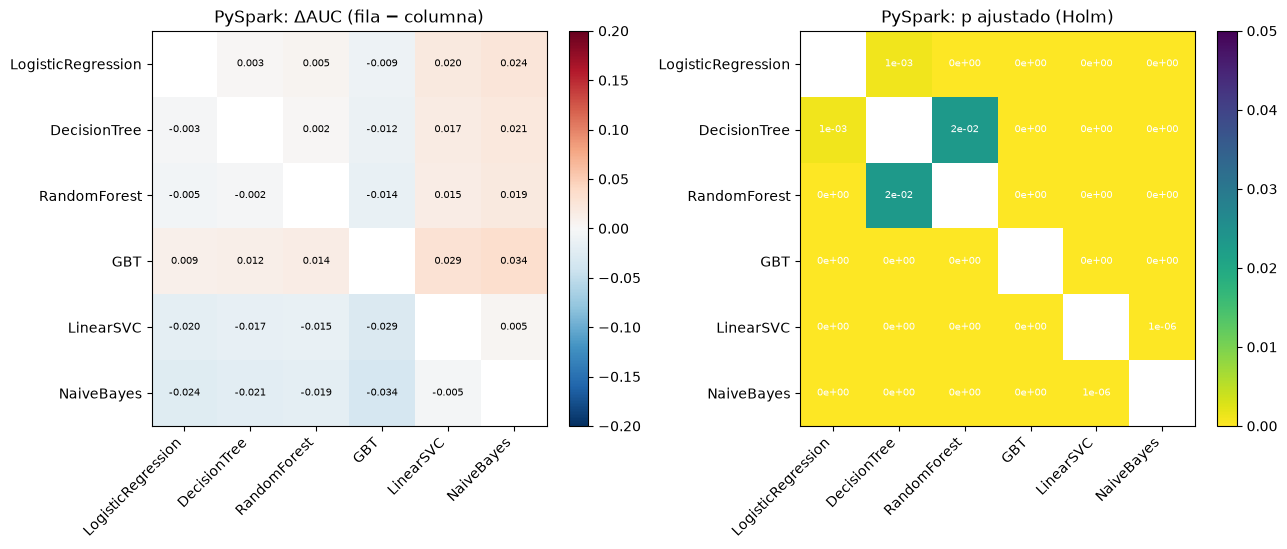

In [10]:
heatmap_delta_y_p(df_within_spark, nombres_modelos, "PySpark", "spark")


Aquí las 15 comparaciones resultaron estadísticamente significativas después de Holm, incluida `DecisionTree` contra `RandomForest` (diferencia de 0,0018, p=0,023), que es significativa pero no prácticamente relevante porque está por debajo de 0,005. El patrón general es el mismo que en scikit-learn: `GBT` es significativamente mejor que todos los demás, y varias diferencias \"significativas\" entre el resto de los modelos son demasiado pequeñas para importar en la práctica.

## 5.7. Comparaciones entre entornos (6 pares, mismo tipo de modelo)

In [11]:
df_between

,modelo_a,modelo_b,auc_a,auc_b,delta_auc,delta_ci_low,delta_ci_high,z,p_value,p_holm,rechaza_h0_holm_0.05,practicamente_sig_(|delta|>=0.005)
0,sk_LogisticRegression,sp_LogisticRegression,0.7221,0.7232,-0.0011,-0.0013,-0.0010,-19.0486,0.00e+00,0.00e+00,True,False
1,sk_DecisionTree,sp_DecisionTree,0.7368,0.7204,0.0164,0.0150,0.0179,22.0984,0.00e+00,0.00e+00,True,True
2,sk_RandomForest,sp_RandomForest,0.7225,0.7185,0.0039,0.0036,0.0043,22.6270,0.00e+00,0.00e+00,True,False
3,sk_GBT,sp_GBT,0.7393,0.7327,0.0066,0.0061,0.0070,28.7635,0.00e+00,0.00e+00,True,True
4,sk_LinearSVC,sp_LinearSVC,0.5594,0.7036,-0.1443,-0.1476,-0.1410,-84.9795,0.00e+00,0.00e+00,True,True
5,sk_NaiveBayes,sp_NaiveBayes,0.6935,0.6990,-0.0055,-0.0059,-0.0052,-33.4124,0.00e+00,0.00e+00,True,True


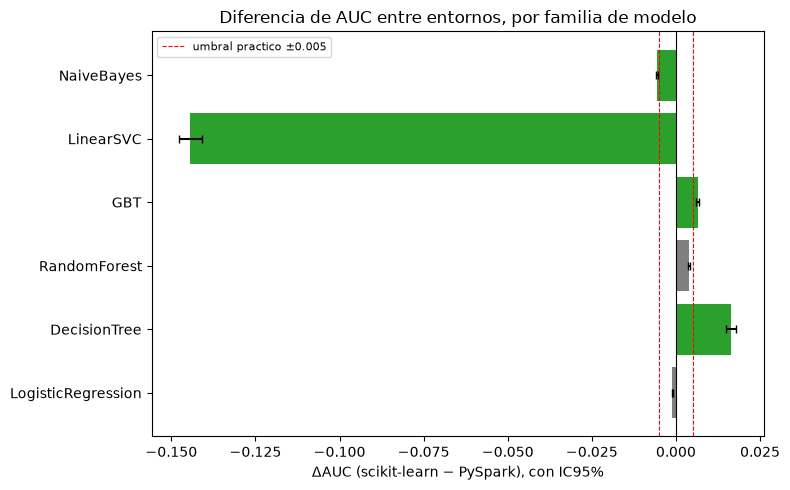

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
y_pos = np.arange(len(df_between))
colores = ["#2ca02c" if s else "#7f7f7f" for s in df_between["practicamente_sig_(|delta|>=0.005)"]]
ax.barh(y_pos, df_between["delta_auc"], xerr=[df_between["delta_auc"]-df_between["delta_ci_low"],
                                                df_between["delta_ci_high"]-df_between["delta_auc"]],
        color=colores, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels([m.split("_",1)[1] for m in df_between["modelo_a"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.005, color="red", linestyle="--", linewidth=0.8, label="umbral practico ±0.005")
ax.axvline(-0.005, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("ΔAUC (scikit-learn − PySpark), con IC95%")
ax.set_title("Diferencia de AUC entre entornos, por familia de modelo")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/delong_between_envs.png", dpi=110)
plt.show()


Con 452.141 observaciones pareadas, las 6 comparaciones entre entornos resultaron estadísticamente significativas (con p prácticamente 0 en todas, incluso después de Holm), porque el tamaño de muestra es tan grande que detecta casi cualquier diferencia distinta de cero. Pero usando el umbral práctico de 0,005 que declaramos de antemano, el panorama cambia bastante:

- `LinearSVC` (diferencia de -0,144): una diferencia enorme, significativa tanto en el sentido estadístico como en el práctico. scikit-learn colapsó (sección 3.7), PySpark no.
- `GBT` (diferencia de +0,0066): scikit-learn (`HistGradientBoostingClassifier`) resultó mejor que Spark (`GBTClassifier`), significativo en los dos sentidos, aunque de magnitud moderada.
- `NaiveBayes` (diferencia de -0,0055): PySpark resultó mejor, apenas por encima del umbral práctico.
- `RandomForest` (diferencia de +0,0039) y `LogisticRegression` (diferencia de -0,0011): estadísticamente significativos por el tamaño de muestra, pero no prácticamente relevantes. En la práctica, los dos entornos producen un modelo equivalente para estas dos familias.
- `DecisionTree` (diferencia de +0,0164): scikit-learn resultó mejor, significativo también en el sentido práctico. Incluso después de corregir el error de la sección 4.2.2, sigue quedando una diferencia real que probablemente se explica por `maxBins`.

## 5.8. Limitaciones de la prueba de DeLong

- Solo compara la capacidad de ordenar casos (AUC), no la calibración ni el desempeño a un umbral de decisión concreto. Dos modelos pueden tener AUC estadísticamente indistinguibles y aun así comportarse muy distinto al umbral que realmente se usaría en producción, como vimos en la sección 3.6, donde varios modelos con AUC cercano a 0,72 predicen 0% de casos positivos al umbral de 0,5. Por eso el enunciado pide complementar con McNemar y bootstrap sobre clasificaciones concretas, en la sección 6.
- Es una prueba asintótica, así que es más confiable con muestras grandes como la nuestra (452 mil filas), y puede ser menos precisa con muestras pequeñas.
- Es muy sensible al tamaño de muestra: como vimos en las secciones 5.5 a 5.7, con una n tan grande casi cualquier diferencia distinta de cero resulta \"significativa\". Por eso es indispensable declarar de antemano un umbral de significancia práctica (en nuestro caso, 0,005), porque sin él la significancia estadística por sí sola no dice si la diferencia realmente importa.
- Asume que las dos muestras de puntajes vienen de las mismas observaciones, es decir del mismo conjunto de prueba, que es justamente lo que verificamos en la sección 5.3 (los mismos 452.141 ids). Si los conjuntos de prueba fueran distintos, la covarianza calculada no tendría sentido, y habría que usar una prueba para muestras independientes, que tiene menos poder estadístico.
- No corrige por sí sola el problema de comparaciones múltiples, por eso aplicamos la corrección de Holm por separado dentro de cada una de las tres familias de comparación (15+15+6), tal como pide el enunciado.